In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

In [2]:
from sklearn.datasets import load_wine
wine=load_wine()

x=wine['data']
y=wine['target']
print(x)
print(y)
print(y.shape)
print(wine)

[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
(178,)
{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+0

In [3]:
#check and spliting
print(x.shape)
print(y.shape)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,shuffle=True)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(178, 13)
(178,)
(142, 13)
(36, 13)
(142,)
(36,)


In [4]:
#missing values
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='mean')

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


pipeline1 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
pipeline1.fit(x_train, y_train)

print(f"Test Accuracy: {pipeline1.score(x_test, y_test):.2f}")

pipeline2=make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=100,random_state=42))
pipeline2.fit(x_train, y_train)
print(f"Test Accuracy: {pipeline2.score(x_test, y_test):.2f}")

Test Accuracy: 1.00
Test Accuracy: 1.00


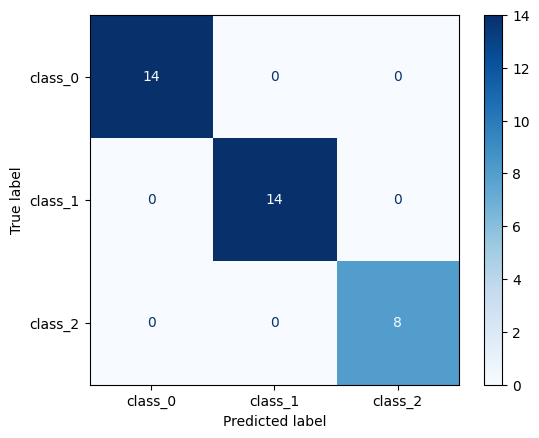

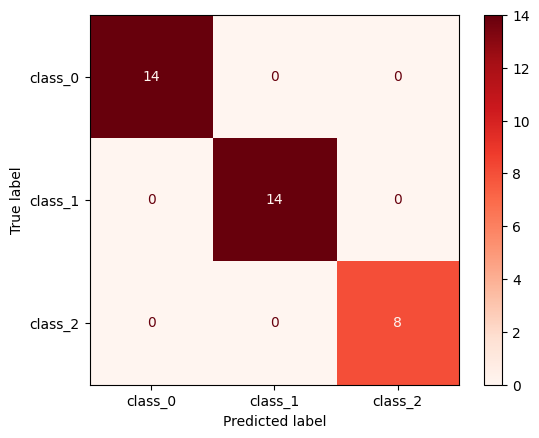

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
y_pred1 = pipeline1.predict(x_test)

Confusion_matric1=confusion_matrix(y_test, y_pred1)
disp = ConfusionMatrixDisplay(confusion_matrix=Confusion_matric1, display_labels=wine['target_names'])
disp.plot(cmap=plt.cm.Blues)
y_pred2 = pipeline2.predict(x_test)

Confusion_matric2=confusion_matrix(y_test, y_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=Confusion_matric2, display_labels=wine['target_names'])
disp.plot(cmap=plt.cm.Reds)